In [ ]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
import funcs

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device being used: {device.type}")

device being used: cuda


## Global parameters

In [ ]:
# model parameters
HIDDEN_LAYERS = [512, 256, 128]
TRAIN_VAL_SPLIT = 0.8

# initial training
N_TRAIN_EPOCHS = 10

# pruning loop
MAX_ALLOWED_ACC_DROP = 0.02
MAX_PRUNE_ROUNDS = 10
PRUNE_FRAC = 0.2
REGROW_FRAC = 0.1
MIN_VAL_ACC = 0.9
N_RETRIAN_EPOCHS = 3

# clustering
N_CLUSTERS = 8

## Setting up data and initial model

In [4]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_size = int(TRAIN_VAL_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [6]:
# Create a DataLoader for batching
batch_size = 256 if device.type == "cuda" else 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [7]:
# Create model and train
model = NeuralNetwork(hidden_sizes=HIDDEN_LAYERS, device=device)

In [8]:
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=N_TRAIN_EPOCHS)

,train_loss,val_loss,val_acc
epoch,,,
1,0.275584,0.095368,0.972938
2,0.188531,0.094180,0.972167
3,0.177378,0.082220,0.976688
4,0.171540,0.086056,0.975812
5,0.164998,0.102356,0.971812
6,0.163187,0.093771,0.973250
7,0.161979,0.078234,0.977146
8,0.163523,0.084613,0.975146
9,0.158315,0.080486,0.977333


In [9]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)

100%|██████████| 188/188 [00:02<00:00, 80.97it/s]


In [10]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%")

Train: 97.22%, Validation: 97.05%


## Prune Neurons and Retrain

In [11]:
from IPython.display import clear_output
import copy



metrics_history = []
prune_history = []

current_model = copy.deepcopy(model)
best_model = copy.deepcopy(current_model)

baseline_val_acc = current_model.accuracy(val_loader)
best_val_acc = baseline_val_acc

round_idx = 0
USE_MAX_ROUNDS = True
while True:
    round_idx+=1
    clear_output(wait=True)
    print(f"\n--- Pruning round {round_idx+1} ---")

    if USE_MAX_ROUNDS and round_idx > MAX_PRUNE_ROUNDS:
        print("Reached maximum pruning rounds.")
        break

    prev_model = copy.deepcopy(current_model)

    print("Getting layer data:")
    layer_data = current_model.get_layer_data(train_loader)

    importance_scores = current_model.compute_neuron_importance(layer_data=layer_data)
    prune_history.append(importance_scores)

    new_model = copy.deepcopy(current_model)
    new_model.prune_hidden_neurons(importance_scores=importance_scores, prune_rate=PRUNE_FRAC, alpha=0.7, regrow_frac=REGROW_FRAC)

    print("Retraining:")
    metrics = new_model.train_model(train_loader, val_loader, epochs=N_RETRIAN_EPOCHS, lr=0.01)
    metrics_history.append(metrics)

    val_acc = metrics['val_acc'].iloc[-1]
    print(f"Validation accuracy after pruning round {round_idx+1}: {val_acc:.4f}")

    acc_drop = baseline_val_acc - val_acc
    
    if acc_drop > MAX_ALLOWED_ACC_DROP:
        print("Accuracy drop exceeded threshold.")
        print("Restoring previous best model")
        current_model = best_model
        break

    best_model = copy.deepcopy(new_model)
    best_val_acc = val_acc
    current_model = new_model

final_model = best_model


--- Pruning round 12 ---
Reached maximum pruning rounds.


In [12]:
for round_idx, metrics in enumerate(metrics_history, start=1):
    print(f"--- Round {round_idx} ---")
    final_val_acc = metrics['val_acc'].iloc[-1]
    print(f"Final validation accuracy: {final_val_acc:.5f}")

--- Round 1 ---
Final validation accuracy: 0.97881
--- Round 2 ---
Final validation accuracy: 0.97515
--- Round 3 ---
Final validation accuracy: 0.97494
--- Round 4 ---
Final validation accuracy: 0.97431
--- Round 5 ---
Final validation accuracy: 0.97627
--- Round 6 ---
Final validation accuracy: 0.97817
--- Round 7 ---
Final validation accuracy: 0.97458
--- Round 8 ---
Final validation accuracy: 0.97704
--- Round 9 ---
Final validation accuracy: 0.97910
--- Round 10 ---
Final validation accuracy: 0.97658


In [13]:
print(f"Test accuracy after pruning: {final_model.accuracy(test_loader)*100:.2f}")

  0%|          | 0/157 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:01<00:00, 81.30it/s]

Test accuracy after pruning: 97.66


## Activation analysis and Neuron Clustering

In [14]:
layer_data_post_pruning = final_model.get_layer_data(train_loader)

100%|██████████| 750/750 [00:10<00:00, 74.36it/s]


In [15]:
for key, value in layer_data_post_pruning.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([192000, 70])
layer_1 has shape: torch.Size([192000, 36])
layer_2 has shape: torch.Size([192000, 21])
layer_3 has shape: torch.Size([192000, 10])


In [16]:
from scipy.cluster.hierarchy import linkage, fcluster

hidden_layers = [k for k in layer_data_post_pruning.keys() if 'layer_' in k]

all_neuron_activations = []
for layer_name in hidden_layers:
    acts = layer_data_post_pruning[layer_name]['post_activation']
    all_neuron_activations.append(acts)

all_neuron_activations = torch.cat(all_neuron_activations, dim=1)

layer_mapping = []
start_idx = 0
for layer_name in hidden_layers:
    n_neurons = layer_data_post_pruning[layer_name]['post_activation'].shape[1]
    end_idx = start_idx + n_neurons
    layer_mapping.append((layer_name, start_idx, end_idx))
    start_idx

neurons_for_clustering = all_neuron_activations.T.numpy()

Z = linkage(neurons_for_clustering, method='ward', metric='euclidean')

n_clusters = N_CLUSTERS
clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

print(f"Total neurons clustered: {neurons_for_clustering.shape[0]}")
print(f"Clusters assigned: {np.unique(clusters)}")

Total neurons clustered: 137
Clusters assigned: [1 2 3 4 5 6 7 8]


In [ ]:
cluster_map = defaultdict(list)
for neuron_idx, cluster_id in enumerate(clusters):
    cluster_map[cluster_id].append(neuron_idx)

cluster_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    per_class_acc = funcs.cluster_criticality_per_class(
        final_model,
        neuron_indices,
        layer_mapping,
        val_loader,
        cluster_id,
        device=device
    )
    cluster_results[cluster_id] = per_class_acc


--- Calculating pre and post-ablation accuracy for cluster 2 ---


100%|██████████| 188/188 [00:02<00:00, 85.67it/s]


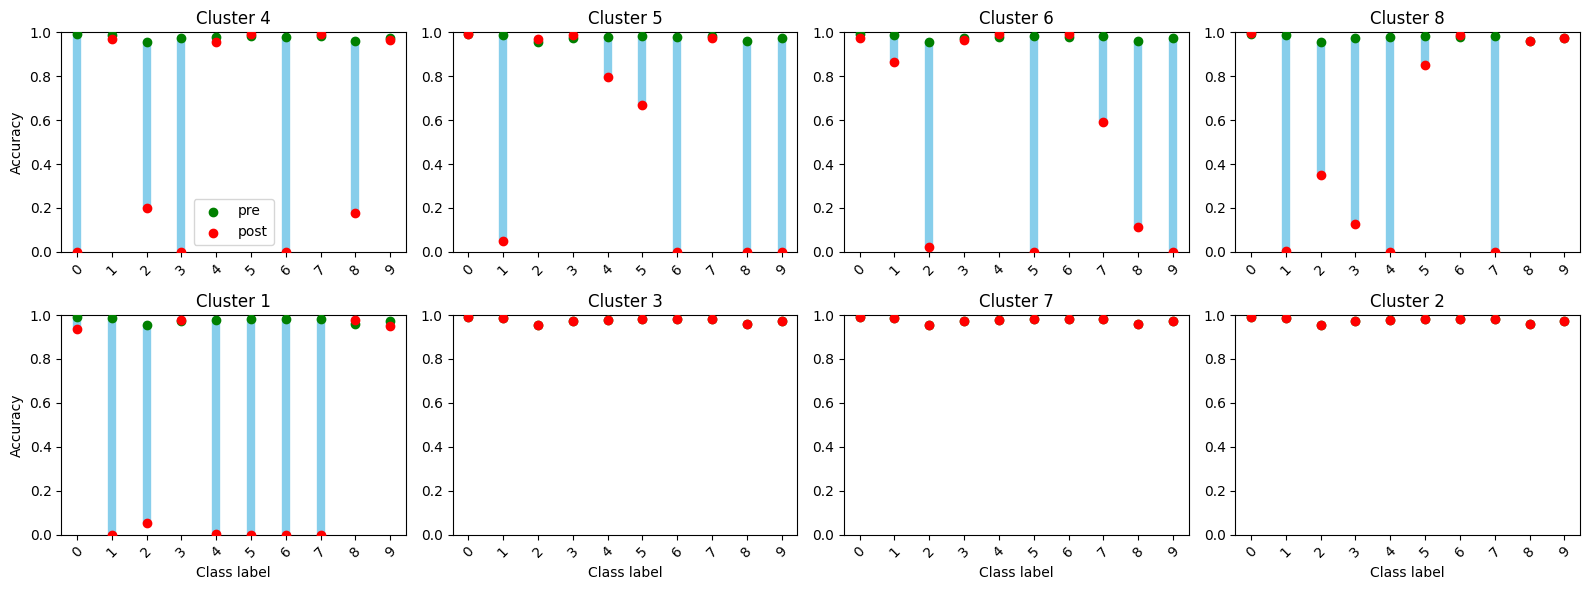

In [ ]:
cluster_class_changes = funcs.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## cluster extraction

In [21]:
cluster_assignment = {} # per layer cluster labels